# 🫀 ACDC Cardiac Cine-MRI Classification Pipeline

**Goal:** Classify cardiac pathologies (NOR, MINF, DCM, HCM, RV) from 4D cine-MRI data using handcrafted temporal & shape features, unsupervised dimensionality reduction, and scikit-learn classifiers.

**Dataset:** [ACDC Challenge](https://www.creatis.insa-lyon.fr/Challenge/acdc/) — 121 training patients, 29 test patients.  
**Pipeline:** NIfTI Loading → CLAHE Enhancement → Temporal-Variance ROI Crop → Feature Extraction → PCA → SVM/RF/MLP Classification

---

## Phase 0 — Environment Setup & Imports

In [2]:
# ─── Core Imports ───────────────────────────────────────────────────────────
import os
import glob
import warnings
import random

import numpy as np
import nibabel as nib
from scipy import ndimage
from skimage.exposure import equalize_adapthist
from skimage.filters import threshold_otsu

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from tqdm.notebook import tqdm

# ─── Global Config ───────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
sns.set_style('darkgrid')

TRAIN_DIR = '../database/training/'
TEST_DIR  = '../database/testing/'
CLASS_NAMES = ['NOR', 'MINF', 'DCM', 'HCM', 'RV']
CLASS_MAP = {name: idx for idx, name in enumerate(CLASS_NAMES)}
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print('✅ All imports loaded successfully.')
print(f'   Training data path: {os.path.abspath(TRAIN_DIR)}')
print(f'   Testing  data path: {os.path.abspath(TEST_DIR)}')

✅ All imports loaded successfully.
   Training data path: /root/bioinfo-playground/database/training
   Testing  data path: /root/bioinfo-playground/database/testing


---
## Phase 1 — Data Loading & Parsing

Load 4D NIfTI volumes (`patientXXX_4d.nii.gz`) and parse pathology labels from `Info.cfg` files.

In [3]:
def parse_info_cfg(cfg_path):
    """
    Parse an ACDC Info.cfg file into a dictionary.
    
    Returns dict with keys: ED, ES, Group, NbFrame, Height, Weight
    """
    meta = {}
    with open(cfg_path, 'r') as f:
        for line in f:
            if ':' in line:
                key, val = line.split(':', 1)
                key, val = key.strip(), val.strip()
                # Convert numeric values
                if key in ('ED', 'ES', 'NbFrame'):
                    meta[key] = int(val)
                elif key in ('Height', 'Weight'):
                    try:
                        meta[key] = float(val)
                    except ValueError:
                        meta[key] = np.nan
                else:
                    meta[key] = val
    return meta


def load_acdc_dataset(base_dir, desc='Loading'):
    """
    Load all patients from an ACDC directory.
    
    For each patient:
      - Reads the 4D NIfTI volume (X, Y, Z, T)
      - Parses Info.cfg for metadata and pathology label
    
    Returns a list of dicts with keys:
      patient_id, data_4d, group, ed, es, nb_frames, height, weight, voxel_spacing
    """
    dataset = []
    patient_dirs = sorted([
        d for d in os.listdir(base_dir)
        if os.path.isdir(os.path.join(base_dir, d)) and d.startswith('patient')
    ])
    
    pbar = tqdm(patient_dirs, desc=desc, unit='patient')
    for patient_id in pbar:
        patient_path = os.path.join(base_dir, patient_id)
        pbar.set_postfix_str(f'{patient_id}')
        
        # Parse metadata
        cfg_path = os.path.join(patient_path, 'Info.cfg')
        if not os.path.exists(cfg_path):
            print(f'  ⚠️  Skipping {patient_id}: No Info.cfg found')
            continue
        meta = parse_info_cfg(cfg_path)
        
        group = meta.get('Group', None)
        if group not in CLASS_MAP:
            print(f'  ⚠️  Skipping {patient_id}: Unknown group "{group}"')
            continue
        
        # Load 4D NIfTI
        nii_path = os.path.join(patient_path, f'{patient_id}_4d.nii.gz')
        if not os.path.exists(nii_path):
            print(f'  ⚠️  Skipping {patient_id}: No 4D NIfTI found')
            continue
        
        nii_img = nib.load(nii_path)
        data_4d = nii_img.get_fdata().astype(np.float32)  # (X, Y, Z, T)
        voxel_spacing = nii_img.header.get_zooms()[:3]  # spatial voxel size
        
        dataset.append({
            'patient_id': patient_id,
            'data_4d': data_4d,
            'group': group,
            'label': CLASS_MAP[group],
            'ed': meta.get('ED', 1),
            'es': meta.get('ES', 1),
            'nb_frames': meta.get('NbFrame', data_4d.shape[-1]),
            'height': meta.get('Height', np.nan),
            'weight': meta.get('Weight', np.nan),
            'voxel_spacing': voxel_spacing,
        })
    
    print(f'\n📊 Successfully loaded {len(dataset)} patients from {os.path.abspath(base_dir)}')
    return dataset

In [4]:
# ─── Load Training Dataset ───────────────────────────────────────────────────
print('='*60)
print(' LOADING TRAINING DATA')
print('='*60)
train_dataset = load_acdc_dataset(TRAIN_DIR, desc='Loading training patients')

# ─── Dataset Summary ─────────────────────────────────────────────────────────
print('\n' + '─'*60)
print(' DATASET SUMMARY')
print('─'*60)

# Class distribution
from collections import Counter
label_counts = Counter(p['group'] for p in train_dataset)
print('\n  Class Distribution:')
for cls in CLASS_NAMES:
    count = label_counts.get(cls, 0)
    bar = '█' * count
    print(f'    {cls:>4s}: {count:3d}  {bar}')

# Shape info
shapes = [p['data_4d'].shape for p in train_dataset]
print(f'\n  Volume shapes (X, Y, Z, T):')
print(f'    Min:  {tuple(min(s[i] for s in shapes) for i in range(4))}')
print(f'    Max:  {tuple(max(s[i] for s in shapes) for i in range(4))}')
print(f'    Mean: {tuple(int(np.mean([s[i] for s in shapes])) for i in range(4))}')
print('─'*60)

 LOADING TRAINING DATA


Loading training patients:   0%|          | 0/121 [00:00<?, ?patient/s]


📊 Successfully loaded 121 patients from /root/bioinfo-playground/database/training

────────────────────────────────────────────────────────────
 DATASET SUMMARY
────────────────────────────────────────────────────────────

  Class Distribution:
     NOR:  23  ███████████████████████
    MINF:  25  █████████████████████████
     DCM:  24  ████████████████████████
     HCM:  26  ██████████████████████████
      RV:  23  ███████████████████████

  Volume shapes (X, Y, Z, T):
    Min:  (154, 154, 6, 12)
    Max:  (428, 512, 18, 35)
    Mean: (220, 245, 9, 27)
────────────────────────────────────────────────────────────


---
## Phase 2 — Preprocessing Pipeline

1. **Intensity Normalization & Enhancement** — Z-score normalization + CLAHE  
2. **Spatial Cropping (ROI Detection)** — Temporal variance map → Otsu threshold → largest connected component → bounding box  
3. **Temporal & Shape Feature Extraction** — Volume curves, ejection fraction, temporal gradients, shape descriptors

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
#  PREPROCESSING FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def normalize_volume(volume_3d):
    """
    Apply Z-score normalization to a 3D volume.
    Clips outliers to [-5, 5] std devs to reduce noise.
    """
    mu = np.mean(volume_3d)
    sigma = np.std(volume_3d)
    if sigma < 1e-8:
        return np.zeros_like(volume_3d)
    normed = (volume_3d - mu) / sigma
    normed = np.clip(normed, -5, 5)
    return normed


def apply_clahe_volume(volume_3d, clip_limit=0.03):
    """
    Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    slice-by-slice on a 3D volume.
    
    Input volume should be normalized to [0, 1] range.
    """
    # Rescale to [0, 1] for CLAHE
    v_min, v_max = volume_3d.min(), volume_3d.max()
    if v_max - v_min < 1e-8:
        return volume_3d
    vol_01 = (volume_3d - v_min) / (v_max - v_min)
    
    enhanced = np.zeros_like(vol_01)
    for z in range(vol_01.shape[2]):
        sl = vol_01[:, :, z]
        if sl.max() - sl.min() > 1e-8:
            enhanced[:, :, z] = equalize_adapthist(sl, clip_limit=clip_limit)
        else:
            enhanced[:, :, z] = sl
    return enhanced


def normalize_and_enhance(volume_3d, clip_limit=0.03):
    """
    Full intensity preprocessing: Z-score → CLAHE.
    Returns the CLAHE-enhanced volume in [0, 1] range.
    """
    normed = normalize_volume(volume_3d)
    enhanced = apply_clahe_volume(normed, clip_limit=clip_limit)
    return enhanced


def compute_temporal_variance_map(data_4d):
    """
    Compute the temporal variance across all frames.
    The moving heart region will have high variance.
    
    Returns:
      var_map: 3D variance map (X, Y, Z)
      bbox: (x_min, x_max, y_min, y_max) bounding box of the heart ROI
      mask: binary mask of the detected heart region
    """
    var_map = np.var(data_4d, axis=-1)  # (X, Y, Z)
    
    # Project variance along Z (max intensity projection) for 2D ROI detection
    var_2d = np.max(var_map, axis=2)  # (X, Y)
    
    # Threshold with Otsu's method
    if var_2d.max() - var_2d.min() < 1e-8:
        # Fallback: use full image
        h, w = var_2d.shape
        return var_map, (0, h, 0, w), np.ones_like(var_2d, dtype=bool)
    
    thresh = threshold_otsu(var_2d)
    binary = var_2d > thresh
    
    # Find the largest connected component (the heart)
    labeled, num_features = ndimage.label(binary)
    if num_features == 0:
        h, w = var_2d.shape
        return var_map, (0, h, 0, w), binary
    
    component_sizes = ndimage.sum(binary, labeled, range(1, num_features + 1))
    largest_label = np.argmax(component_sizes) + 1
    heart_mask = labeled == largest_label
    
    # Extract bounding box with padding
    rows = np.any(heart_mask, axis=1)
    cols = np.any(heart_mask, axis=0)
    x_min, x_max = np.where(rows)[0][[0, -1]]
    y_min, y_max = np.where(cols)[0][[0, -1]]
    
    # Add 10% padding
    pad_x = max(int(0.1 * (x_max - x_min)), 5)
    pad_y = max(int(0.1 * (y_max - y_min)), 5)
    x_min = max(0, x_min - pad_x)
    x_max = min(data_4d.shape[0], x_max + pad_x + 1)
    y_min = max(0, y_min - pad_y)
    y_max = min(data_4d.shape[1], y_max + pad_y + 1)
    
    return var_map, (x_min, x_max, y_min, y_max), heart_mask


def crop_roi(data_4d, bbox):
    """
    Crop the 4D volume to the heart ROI bounding box.
    Returns cropped 4D array (cropped_X, cropped_Y, Z, T)
    """
    x_min, x_max, y_min, y_max = bbox
    return data_4d[x_min:x_max, y_min:y_max, :, :]


print('✅ Preprocessing functions defined.')

✅ Preprocessing functions defined.


### 🔬 Intermediate Image Sampling — Preprocessing Visualization

Display the preprocessing progression for a randomly sampled patient:

🎲 Sampled patient: patient082 (Group: RV)
   Volume shape: (224, 154, 16, 17)


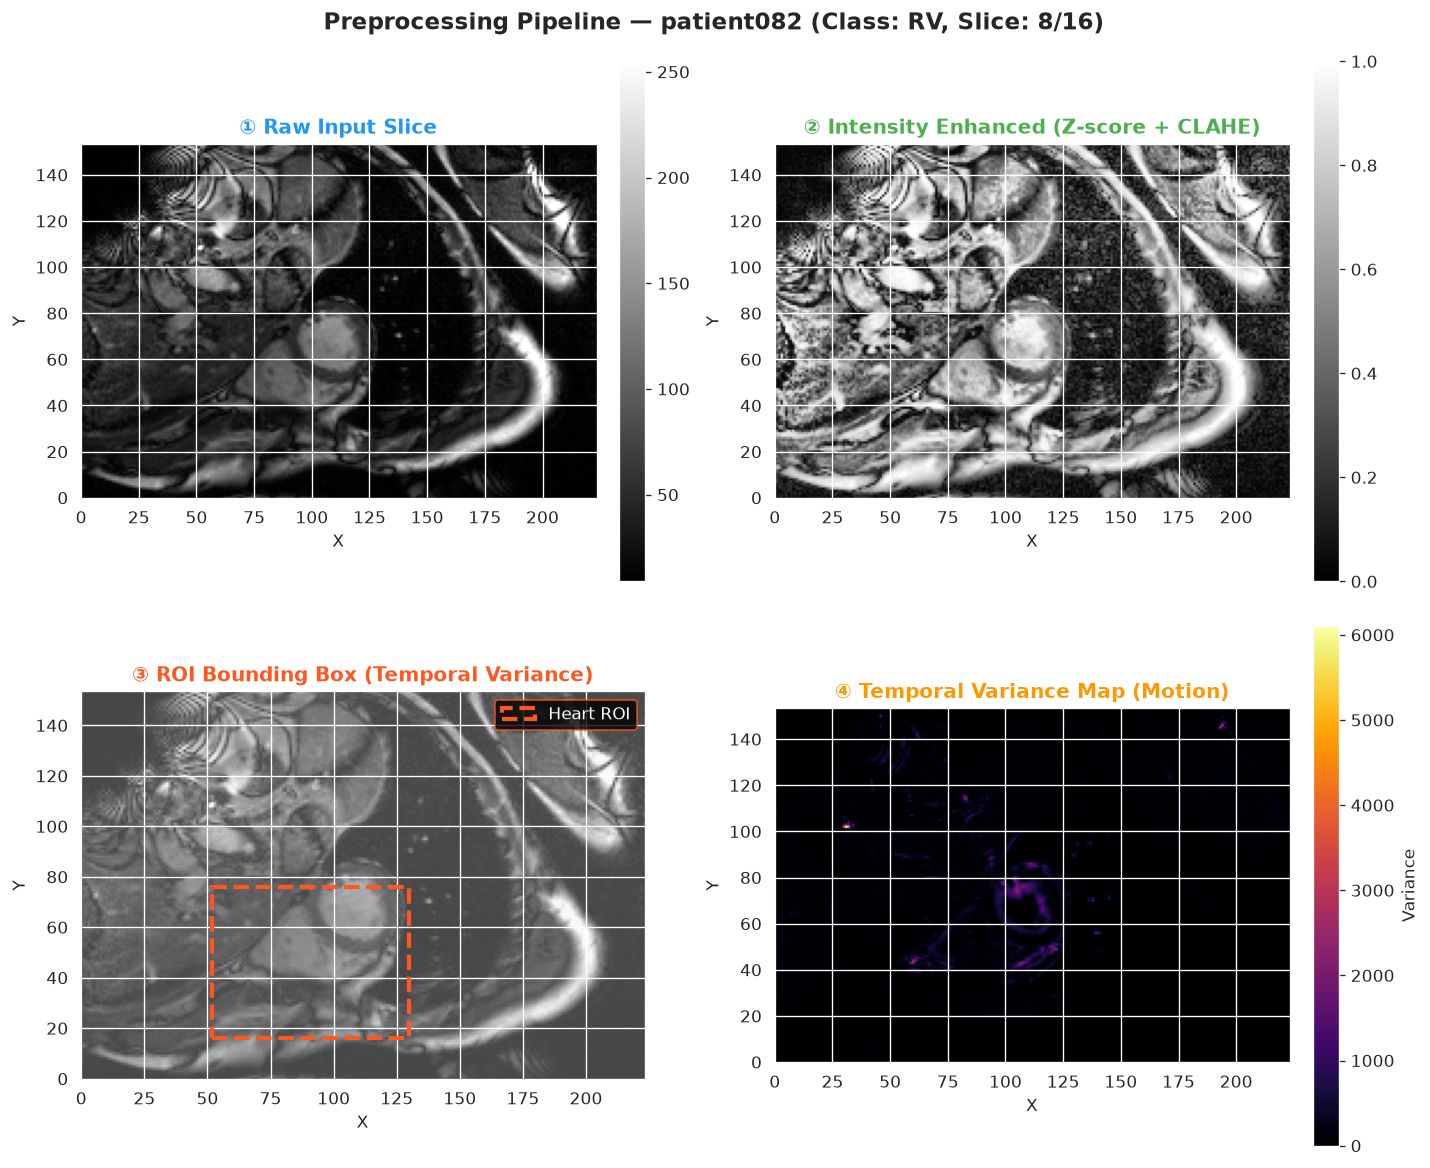


  📐 Original volume shape:  (224, 154, 16, 17)
  📐 Cropped ROI shape:      (78, 60, 16, 17)
  📐 Bounding box (x,y):     (52:130, 16:76)


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
#  VISUALIZATION: Preprocessing Pipeline on a Random Patient
# ═══════════════════════════════════════════════════════════════════════════════

sample_patient = random.choice(train_dataset)
print(f'🎲 Sampled patient: {sample_patient["patient_id"]} (Group: {sample_patient["group"]})')
print(f'   Volume shape: {sample_patient["data_4d"].shape}')

data_4d = sample_patient['data_4d']
n_slices = data_4d.shape[2]
mid_z = n_slices // 2  # Mid-ventricular slice
mid_t = 0  # First time frame for spatial views

# Step 1: Raw slice
raw_slice = data_4d[:, :, mid_z, mid_t]

# Step 2: Normalized + CLAHE enhanced slice
raw_vol_t0 = data_4d[:, :, :, mid_t]
enhanced_vol = normalize_and_enhance(raw_vol_t0)
enhanced_slice = enhanced_vol[:, :, mid_z]

# Step 3: ROI crop detection
var_map, bbox, heart_mask = compute_temporal_variance_map(data_4d)
cropped_4d = crop_roi(data_4d, bbox)
cropped_slice = cropped_4d[:, :, min(mid_z, cropped_4d.shape[2]-1), mid_t]

# Step 4: Temporal variance map
var_slice = var_map[:, :, mid_z]

# ─── Plot 2×2 Grid ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(
    f'Preprocessing Pipeline — {sample_patient["patient_id"]} '
    f'(Class: {sample_patient["group"]}, Slice: {mid_z}/{n_slices})',
    fontsize=14, fontweight='bold', y=0.98
)

# Panel 1: Raw input
ax = axes[0, 0]
im1 = ax.imshow(raw_slice.T, cmap='gray', origin='lower')
ax.set_title('① Raw Input Slice', fontweight='bold', color='#2196F3')
ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

# Panel 2: Enhanced/Normalized
ax = axes[0, 1]
im2 = ax.imshow(enhanced_slice.T, cmap='gray', origin='lower')
ax.set_title('② Intensity Enhanced (Z-score + CLAHE)', fontweight='bold', color='#4CAF50')
ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

# Panel 3: Cropped ROI with bounding box overlay
ax = axes[1, 0]
ax.imshow(raw_slice.T, cmap='gray', origin='lower', alpha=0.7)
x_min, x_max, y_min, y_max = bbox
rect = patches.Rectangle(
    (x_min, y_min), x_max - x_min, y_max - y_min,
    linewidth=2.5, edgecolor='#FF5722', facecolor='none', linestyle='--'
)
ax.add_patch(rect)
ax.set_title('③ ROI Bounding Box (Temporal Variance)', fontweight='bold', color='#FF5722')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.legend(['Heart ROI'], loc='upper right', 
          facecolor='black', edgecolor='#FF5722', labelcolor='white')

# Panel 4: Temporal variance/motion map
ax = axes[1, 1]
im4 = ax.imshow(var_slice.T, cmap='inferno', origin='lower')
ax.set_title('④ Temporal Variance Map (Motion)', fontweight='bold', color='#FF9800')
ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04, label='Variance')

plt.tight_layout()
plt.show()

print(f'\n  📐 Original volume shape:  {data_4d.shape}')
print(f'  📐 Cropped ROI shape:      {cropped_4d.shape}')
print(f'  📐 Bounding box (x,y):     ({x_min}:{x_max}, {y_min}:{y_max})')

---
### Feature Engineering

Extract a rich set of temporal, shape, and statistical features from each patient's 4D volume.

In [7]:
def extract_features(data_4d, meta, bbox):
    """
    Extract a comprehensive feature vector from a single patient's 4D volume.
    
    Features extracted:
      - Temporal variance statistics (from ROI region)
      - Volume curve analysis (ejection fraction approximation)
      - Temporal gradient statistics (frame-to-frame changes)
      - Shape descriptors (ROI bounding box ratios)
      - Clinical metadata (height, weight, BMI)
    
    Args:
        data_4d: 4D numpy array (X, Y, Z, T)
        meta: dict with patient metadata (height, weight, ed, es, nb_frames, voxel_spacing)
        bbox: (x_min, x_max, y_min, y_max) heart ROI bounding box
    
    Returns:
        features: 1D numpy array of extracted features
        feature_names: list of feature name strings
    """
    features = []
    feature_names = []
    
    x_min, x_max, y_min, y_max = bbox
    n_x, n_y, n_z, n_t = data_4d.shape
    
    # Crop to ROI
    roi_4d = data_4d[x_min:x_max, y_min:y_max, :, :]
    
    # Use the middle third of slices (mid-ventricular region)
    z_start = n_z // 3
    z_end = max(z_start + 1, 2 * n_z // 3)
    mid_roi = roi_4d[:, :, z_start:z_end, :]
    
    # ─── 1. Temporal Variance Features ──────────────────────────────────────
    var_map = np.var(mid_roi, axis=-1)  # (X', Y', Z_mid)
    for stat_name, stat_fn in [('mean', np.mean), ('std', np.std), 
                                ('max', np.max), ('p25', lambda x: np.percentile(x, 25)),
                                ('p50', lambda x: np.percentile(x, 50)),
                                ('p75', lambda x: np.percentile(x, 75)),
                                ('p95', lambda x: np.percentile(x, 95))]:
        features.append(stat_fn(var_map))
        feature_names.append(f'tvar_{stat_name}')
    
    # Ratio of high-variance voxels (motion fraction)
    if var_map.max() > 1e-8:
        try:
            thresh = threshold_otsu(var_map)
            motion_frac = np.mean(var_map > thresh)
        except ValueError:
            motion_frac = 0.0
    else:
        motion_frac = 0.0
    features.append(motion_frac)
    feature_names.append('tvar_motion_fraction')
    
    # ─── 2. Volume Curve Analysis ───────────────────────────────────────────
    # Sum of intensities per frame in ROI → proxy for blood pool volume
    volume_curve = np.array([np.sum(mid_roi[:, :, :, t]) for t in range(n_t)])
    if volume_curve.max() > 1e-8:
        volume_curve_norm = volume_curve / volume_curve.max()
    else:
        volume_curve_norm = volume_curve
    
    # Ejection fraction approximation: (EDV - ESV) / EDV
    ed_frame = meta.get('ed', 0) - 1  # 0-indexed
    es_frame = meta.get('es', 0) - 1
    ed_frame = np.clip(ed_frame, 0, n_t - 1)
    es_frame = np.clip(es_frame, 0, n_t - 1)
    
    edv = volume_curve[ed_frame]
    esv = volume_curve[es_frame]
    ef_approx = (edv - esv) / max(edv, 1e-8)
    
    features.extend([
        np.mean(volume_curve_norm),
        np.std(volume_curve_norm),
        np.max(volume_curve_norm) - np.min(volume_curve_norm),  # range
        ef_approx,
        edv / max(volume_curve.max(), 1e-8),  # normalized ED volume
        esv / max(volume_curve.max(), 1e-8),  # normalized ES volume
    ])
    feature_names.extend([
        'vol_mean', 'vol_std', 'vol_range', 'ef_approx',
        'edv_norm', 'esv_norm'
    ])
    
    # ─── 3. Temporal Gradient Features ──────────────────────────────────────
    # Frame-to-frame intensity changes (cardiac motion dynamics)
    if n_t > 1:
        temporal_grad = np.diff(mid_roi.astype(np.float64), axis=-1)  # (X', Y', Z_mid, T-1)
        grad_magnitudes = np.sqrt(np.mean(temporal_grad**2, axis=(0, 1, 2)))  # per-frame RMS
        
        features.extend([
            np.mean(grad_magnitudes),
            np.std(grad_magnitudes),
            np.max(grad_magnitudes),
            np.argmax(grad_magnitudes) / max(len(grad_magnitudes) - 1, 1),  # phase of max contraction
        ])
        feature_names.extend([
            'tgrad_mean', 'tgrad_std', 'tgrad_max', 'tgrad_maxphase'
        ])
    else:
        features.extend([0, 0, 0, 0])
        feature_names.extend(['tgrad_mean', 'tgrad_std', 'tgrad_max', 'tgrad_maxphase'])
    
    # Volume curve temporal gradients
    if n_t > 1:
        vol_grad = np.diff(volume_curve_norm)
        features.extend([
            np.mean(vol_grad),
            np.std(vol_grad),
            np.max(np.abs(vol_grad)),  # max contraction/expansion rate
        ])
        feature_names.extend(['volgrad_mean', 'volgrad_std', 'volgrad_maxabs'])
    else:
        features.extend([0, 0, 0])
        feature_names.extend(['volgrad_mean', 'volgrad_std', 'volgrad_maxabs'])
    
    # ─── 4. Shape Descriptors ───────────────────────────────────────────────
    roi_width = x_max - x_min
    roi_height = y_max - y_min
    roi_aspect_ratio = roi_width / max(roi_height, 1)
    roi_area_fraction = (roi_width * roi_height) / max(n_x * n_y, 1)
    
    features.extend([
        roi_width / n_x,       # normalized ROI width
        roi_height / n_y,      # normalized ROI height
        roi_aspect_ratio,
        roi_area_fraction,
        n_z,                   # number of slices (depth)
    ])
    feature_names.extend([
        'roi_width_norm', 'roi_height_norm', 'roi_aspect',
        'roi_area_frac', 'n_slices'
    ])
    
    # ─── 5. Clinical Metadata ───────────────────────────────────────────────
    height = meta.get('height', np.nan)
    weight = meta.get('weight', np.nan)
    bmi = weight / max((height / 100)**2, 1e-8) if not (np.isnan(height) or np.isnan(weight)) else np.nan
    
    features.extend([height, weight, bmi, n_t])
    feature_names.extend(['height', 'weight', 'bmi', 'n_frames'])
    
    # ─── 6. Intensity Distribution Features (enhanced) ──────────────────────
    # Statistics of the enhanced mid-ventricular ROI at ED and ES frames
    for frame_name, frame_idx in [('ed', ed_frame), ('es', es_frame)]:
        frame_vol = mid_roi[:, :, :, frame_idx]
        features.extend([
            np.mean(frame_vol),
            np.std(frame_vol),
            np.percentile(frame_vol, 5),
            np.percentile(frame_vol, 95),
        ])
        feature_names.extend([
            f'{frame_name}_int_mean', f'{frame_name}_int_std',
            f'{frame_name}_int_p5', f'{frame_name}_int_p95'
        ])
    
    return np.array(features, dtype=np.float64), feature_names


print('✅ Feature extraction function defined.')

# Quick test on the sampled patient
_test_feats, _test_names = extract_features(
    sample_patient['data_4d'], 
    sample_patient, 
    bbox
)
print(f'   Feature vector length: {len(_test_feats)}')
print(f'   Feature names: {_test_names}')

✅ Feature extraction function defined.
   Feature vector length: 38
   Feature names: ['tvar_mean', 'tvar_std', 'tvar_max', 'tvar_p25', 'tvar_p50', 'tvar_p75', 'tvar_p95', 'tvar_motion_fraction', 'vol_mean', 'vol_std', 'vol_range', 'ef_approx', 'edv_norm', 'esv_norm', 'tgrad_mean', 'tgrad_std', 'tgrad_max', 'tgrad_maxphase', 'volgrad_mean', 'volgrad_std', 'volgrad_maxabs', 'roi_width_norm', 'roi_height_norm', 'roi_aspect', 'roi_area_frac', 'n_slices', 'height', 'weight', 'bmi', 'n_frames', 'ed_int_mean', 'ed_int_std', 'ed_int_p5', 'ed_int_p95', 'es_int_mean', 'es_int_std', 'es_int_p5', 'es_int_p95']


---
## Phase 3 — Feature Matrix Construction

Apply the full preprocessing + feature extraction pipeline to all training patients.

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
#  BUILD FEATURE MATRIX FROM TRAINING DATA
# ═══════════════════════════════════════════════════════════════════════════════

def build_feature_matrix(dataset, desc='Extracting features'):
    """
    Process all patients: temporal variance ROI detection → feature extraction.
    Returns X (feature matrix), y (labels), feature_names, patient_ids.
    """
    X_list = []
    y_list = []
    patient_ids = []
    feature_names = None
    
    pbar = tqdm(dataset, desc=desc, unit='patient')
    for i, patient in enumerate(pbar):
        pid = patient['patient_id']
        pbar.set_postfix_str(f'{pid} ({patient["group"]})')
        
        data_4d = patient['data_4d']
        
        # ROI detection via temporal variance
        _, bbox, _ = compute_temporal_variance_map(data_4d)
        
        # Extract features
        feats, names = extract_features(data_4d, patient, bbox)
        
        # Handle NaN/Inf values
        feats = np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)
        
        X_list.append(feats)
        y_list.append(patient['label'])
        patient_ids.append(pid)
        
        if feature_names is None:
            feature_names = names
    
    X = np.array(X_list)
    y = np.array(y_list)
    
    print(f'\n📊 Feature extraction complete!')
    print(f'   Feature matrix shape: {X.shape}  (patients × features)')
    print(f'   Label vector shape:   {y.shape}')
    print(f'   Class distribution:   {dict(zip(*np.unique(y, return_counts=True)))}')
    
    return X, y, feature_names, patient_ids


print('Building training feature matrix...')
X_train, y_train, feature_names, train_patient_ids = build_feature_matrix(
    train_dataset, desc='Feature extraction [Train]'
)

Building training feature matrix...


Feature extraction [Train]:   0%|          | 0/121 [00:00<?, ?patient/s]


📊 Feature extraction complete!
   Feature matrix shape: (121, 38)  (patients × features)
   Label vector shape:   (121,)
   Class distribution:   {np.int64(0): np.int64(23), np.int64(1): np.int64(25), np.int64(2): np.int64(24), np.int64(3): np.int64(26), np.int64(4): np.int64(23)}


---
## Phase 4 — Unsupervised Feature Extraction & Dimensionality Reduction

**Step A:** Apply PCA for variance-preserving dimensionality reduction, then t-SNE for 2D visualization.

Scaled feature matrix shape: (121, 38)

🔬 PCA Results:
   Original dimensions:  38
   PCA dimensions:       13
   Total variance retained: 0.9602 (96.0%)


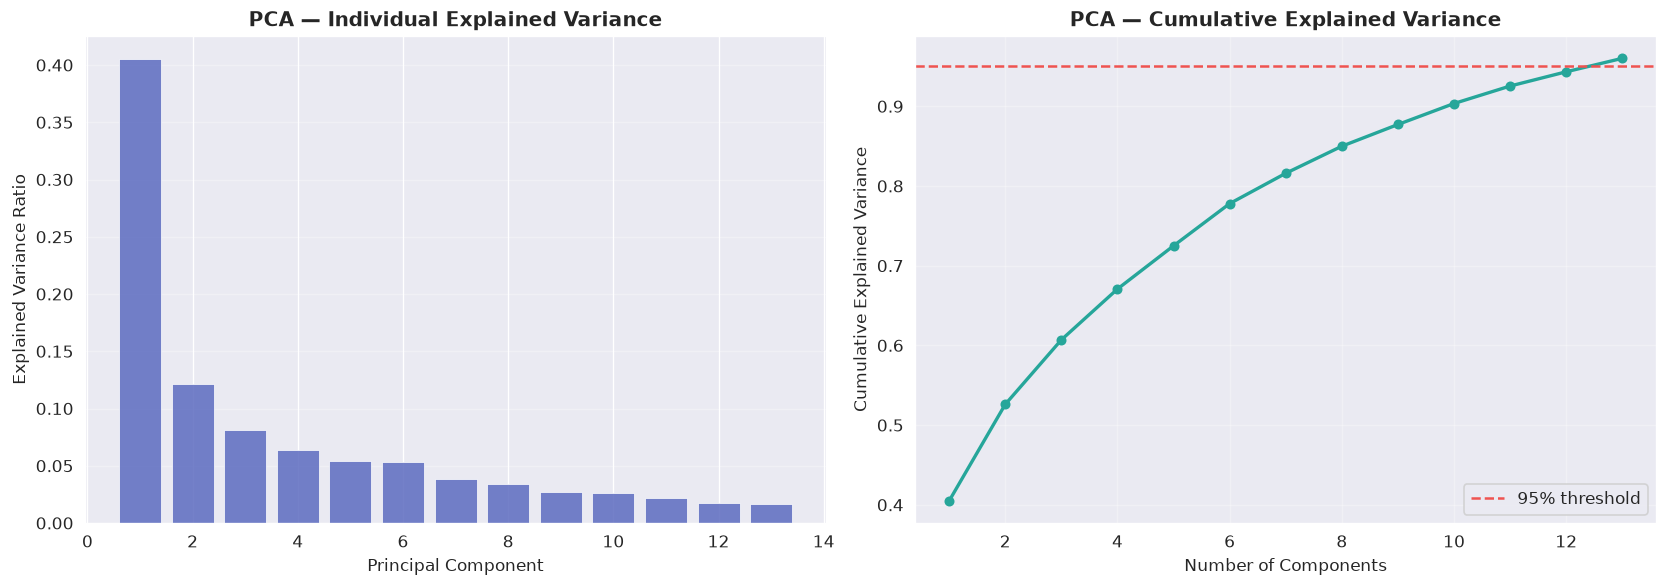

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
#  PCA — Dimensionality Reduction
# ═══════════════════════════════════════════════════════════════════════════════

# Standardize features first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
print(f'Scaled feature matrix shape: {X_train_scaled.shape}')

# PCA: retain 95% of variance
pca = PCA(n_components=0.95, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)

print(f'\n🔬 PCA Results:')
print(f'   Original dimensions:  {X_train_scaled.shape[1]}')
print(f'   PCA dimensions:       {X_train_pca.shape[1]}')
print(f'   Total variance retained: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.1f}%)')

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
       pca.explained_variance_ratio_, 
       color='#5C6BC0', alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Individual Explained Variance', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.plot(range(1, len(cumvar) + 1), cumvar, 'o-', color='#26A69A', linewidth=2, markersize=5)
ax.axhline(y=0.95, color='#EF5350', linestyle='--', linewidth=1.5, label='95% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Cumulative Explained Variance', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Computing t-SNE embedding (this may take a moment)...


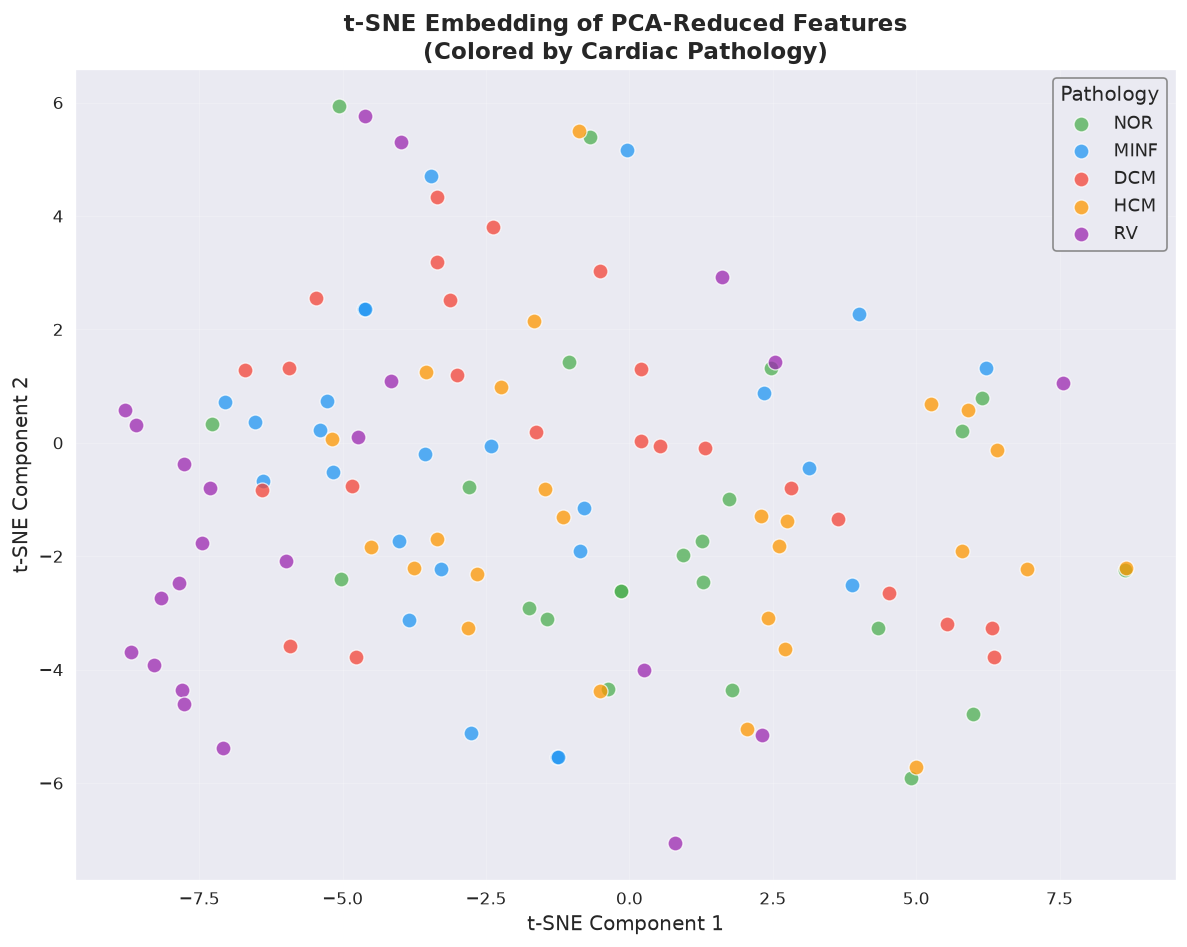


✅ t-SNE embedding computed. Shape: (121, 2)


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
#  t-SNE — 2D Visualization of Latent Space
# ═══════════════════════════════════════════════════════════════════════════════

print('Computing t-SNE embedding (this may take a moment)...')
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=min(30, len(X_train_pca)-1),
            learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_train_pca)

# Color palette for 5 classes
palette = {'NOR': '#4CAF50', 'MINF': '#2196F3', 'DCM': '#F44336', 'HCM': '#FF9800', 'RV': '#9C27B0'}

fig, ax = plt.subplots(figsize=(10, 8))

for cls_name, cls_idx in CLASS_MAP.items():
    mask = y_train == cls_idx
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=palette[cls_name], label=cls_name,
        s=80, alpha=0.75, edgecolors='white', linewidth=0.8
    )

ax.set_xlabel('t-SNE Component 1', fontsize=12)
ax.set_ylabel('t-SNE Component 2', fontsize=12)
ax.set_title('t-SNE Embedding of PCA-Reduced Features\n(Colored by Cardiac Pathology)',
             fontsize=14, fontweight='bold')
ax.legend(title='Pathology', fontsize=11, title_fontsize=12, 
          loc='best', framealpha=0.9, edgecolor='gray')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f'\n✅ t-SNE embedding computed. Shape: {X_tsne.shape}')

---
## Phase 5 — Classification with Cross-Validation

**Step B:** Train classifiers (Random Forest, SVM, MLP) on PCA-reduced features using 5-fold stratified cross-validation with grid search.

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
#  MODEL SELECTION — Grid Search with Cross-Validation
# ═══════════════════════════════════════════════════════════════════════════════

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Define candidate models and their hyperparameter grids
model_configs = {
    'RandomForest': {
        'estimator': RandomForestClassifier(random_state=RANDOM_SEED),
        'param_grid': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 20, None],
            'min_samples_split': [2, 5],
        }
    },
    'SVM': {
        'estimator': SVC(random_state=RANDOM_SEED, probability=True),
        'param_grid': {
            'C': [0.1, 1.0, 10.0],
            'kernel': ['rbf', 'poly'],
            'gamma': ['scale', 'auto'],
        }
    },
    'MLP': {
        'estimator': MLPClassifier(random_state=RANDOM_SEED, max_iter=1000, early_stopping=True),
        'param_grid': {
            'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
            'alpha': [1e-4, 1e-3, 1e-2],
        }
    }
}

results = {}
best_overall_score = -1
best_overall_model = None
best_overall_name = None

model_pbar = tqdm(model_configs.items(), desc='Model Selection', total=len(model_configs))

for model_name, config in model_pbar:
    model_pbar.set_postfix_str(f'Training {model_name}')
    print(f'\n{"="*60}')
    print(f'  🔍 Grid Search: {model_name}')
    print(f'{"="*60}')
    
    grid_search = GridSearchCV(
        estimator=config['estimator'],
        param_grid=config['param_grid'],
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1,
        refit=True,
        return_train_score=True
    )
    
    grid_search.fit(X_train_pca, y_train)
    
    # Report results
    print(f'\n  Best parameters: {grid_search.best_params_}')
    print(f'  Best CV F1 (macro): {grid_search.best_score_:.4f}')
    
    # Per-fold breakdown of the best estimator
    best_idx = grid_search.best_index_
    cv_results = grid_search.cv_results_
    
    print(f'\n  Per-fold scores (best config):')
    for fold in range(5):
        train_score = cv_results[f'split{fold}_train_score'][best_idx]
        val_score = cv_results[f'split{fold}_test_score'][best_idx]
        print(f'    Fold {fold+1}: Train F1={train_score:.4f}  |  Val F1={val_score:.4f}')
    
    mean_train = np.mean([cv_results[f'split{fold}_train_score'][best_idx] for fold in range(5)])
    mean_val = grid_search.best_score_
    print(f'    ─────────────────────────────────────────')
    print(f'    Mean:  Train F1={mean_train:.4f}  |  Val F1={mean_val:.4f}')
    
    results[model_name] = {
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'best_estimator': grid_search.best_estimator_,
        'cv_results': cv_results,
        'best_idx': best_idx,
    }
    
    if grid_search.best_score_ > best_overall_score:
        best_overall_score = grid_search.best_score_
        best_overall_model = grid_search.best_estimator_
        best_overall_name = model_name

print(f'\n{"═"*60}')
print(f'  🏆 BEST MODEL: {best_overall_name}')
print(f'     CV F1 (macro): {best_overall_score:.4f}')
print(f'     Parameters: {results[best_overall_name]["best_params"]}')
print(f'{"═"*60}')

Model Selection:   0%|          | 0/3 [00:00<?, ?it/s]


  🔍 Grid Search: RandomForest
Fitting 5 folds for each of 24 candidates, totalling 120 fits



  Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
  Best CV F1 (macro): 0.3531

  Per-fold scores (best config):
    Fold 1: Train F1=1.0000  |  Val F1=0.4033
    Fold 2: Train F1=1.0000  |  Val F1=0.3861
    Fold 3: Train F1=1.0000  |  Val F1=0.2956
    Fold 4: Train F1=1.0000  |  Val F1=0.3848
    Fold 5: Train F1=1.0000  |  Val F1=0.2956
    ─────────────────────────────────────────
    Mean:  Train F1=1.0000  |  Val F1=0.3531

  🔍 Grid Search: SVM
Fitting 5 folds for each of 12 candidates, totalling 60 fits

  Best parameters: {'C': 1.0, 'gamma': 'auto', 'kernel': 'rbf'}
  Best CV F1 (macro): 0.4001

  Per-fold scores (best config):
    Fold 1: Train F1=0.7978  |  Val F1=0.4841
    Fold 2: Train F1=0.7720  |  Val F1=0.3137
    Fold 3: Train F1=0.8487  |  Val F1=0.4010
    Fold 4: Train F1=0.8476  |  Val F1=0.3794
    Fold 5: Train F1=0.8103  |  Val F1=0.4225
    ─────────────────────────────────────────
    Mean:  Train F1=0.8153  |  Val F1=0.4001




  Best parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (128,)}
  Best CV F1 (macro): 0.3014

  Per-fold scores (best config):
    Fold 1: Train F1=0.4411  |  Val F1=0.3349
    Fold 2: Train F1=0.3591  |  Val F1=0.4538
    Fold 3: Train F1=0.2059  |  Val F1=0.0992
    Fold 4: Train F1=0.6620  |  Val F1=0.3883
    Fold 5: Train F1=0.3371  |  Val F1=0.2310
    ─────────────────────────────────────────
    Mean:  Train F1=0.4011  |  Val F1=0.3014

════════════════════════════════════════════════════════════
  🏆 BEST MODEL: SVM
     CV F1 (macro): 0.4001
     Parameters: {'C': 1.0, 'gamma': 'auto', 'kernel': 'rbf'}
════════════════════════════════════════════════════════════



────────────────────────────────────────────────────────────
 MODEL COMPARISON SUMMARY
────────────────────────────────────────────────────────────
Model                Best CV F1 Best Params
────────────────────────────────────────────────────────────
SVM                      0.4001   {'C': 1.0, 'gamma': 'auto', 'kernel': 'rbf'} ← BEST
RandomForest             0.3531   {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
MLP                      0.3014   {'alpha': 0.0001, 'hidden_layer_sizes': (128,)}
────────────────────────────────────────────────────────────


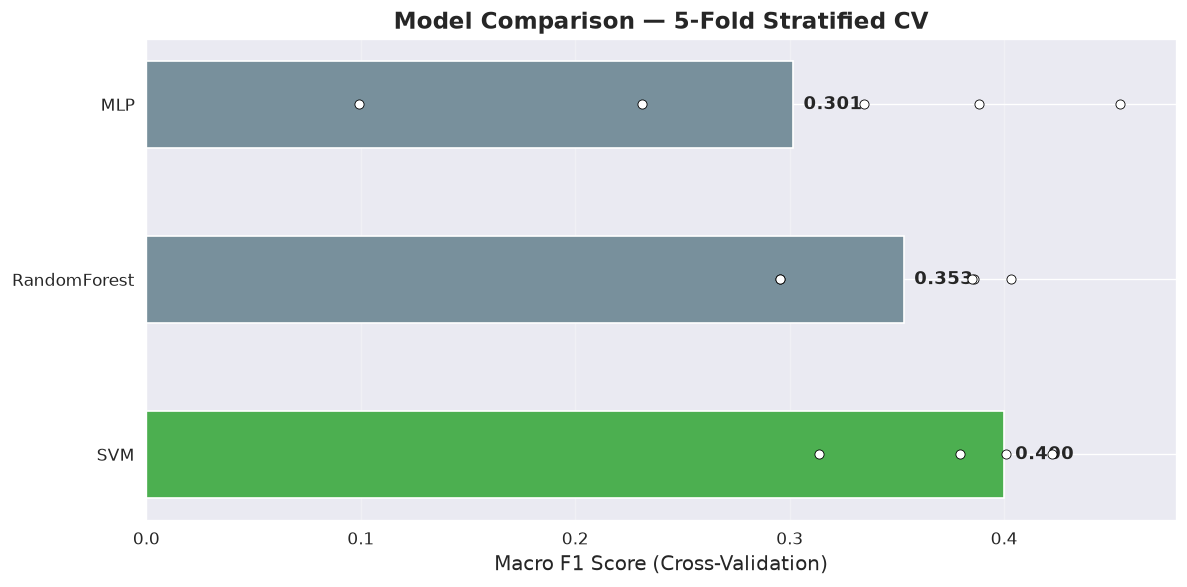

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CROSS-VALIDATION RESULTS SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

print('\n' + '─'*60)
print(' MODEL COMPARISON SUMMARY')
print('─'*60)
print(f'{"Model":<18} {"Best CV F1":>12} {"Best Params"}')
print('─'*60)
for name, res in sorted(results.items(), key=lambda x: -x[1]['best_score']):
    marker = ' ← BEST' if name == best_overall_name else ''
    print(f'{name:<18} {res["best_score"]:>12.4f}   {res["best_params"]}{marker}')
print('─'*60)

# ─── Visualization: Model comparison bar chart ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

model_names_sorted = sorted(results.keys(), key=lambda x: -results[x]['best_score'])
scores = [results[name]['best_score'] for name in model_names_sorted]
colors = ['#4CAF50' if name == best_overall_name else '#78909C' for name in model_names_sorted]

bars = ax.barh(model_names_sorted, scores, color=colors, edgecolor='white', height=0.5)

# Add fold scores as scatter points
for i, name in enumerate(model_names_sorted):
    res = results[name]
    fold_scores = [res['cv_results'][f'split{f}_test_score'][res['best_idx']] for f in range(5)]
    ax.scatter(fold_scores, [i]*5, color='white', s=30, zorder=5, edgecolors='black', linewidth=0.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Macro F1 Score (Cross-Validation)', fontsize=12)
ax.set_title('Model Comparison — 5-Fold Stratified CV', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(scores) + 0.08)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Phase 6 — Test Set Evaluation

Apply the full pipeline to the unseen test set and report final metrics.

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
#  LOAD & PREPROCESS TEST SET
# ═══════════════════════════════════════════════════════════════════════════════

print('='*60)
print(' LOADING TEST DATA')
print('='*60)
test_dataset = load_acdc_dataset(TEST_DIR, desc='Loading test patients')

# Build test feature matrix using the same pipeline
print('\nExtracting test features...')
X_test, y_test, _, test_patient_ids = build_feature_matrix(
    test_dataset, desc='Feature extraction [Test]'
)

# Apply the SAME scaler and PCA transform (fitted on training data)
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)

print(f'\n📊 Test set ready:')
print(f'   Test feature matrix: {X_test_pca.shape}')
print(f'   Test labels:         {y_test.shape}')

 LOADING TEST DATA


Loading test patients:   0%|          | 0/29 [00:00<?, ?patient/s]


📊 Successfully loaded 29 patients from /root/bioinfo-playground/database/testing

Extracting test features...


Feature extraction [Test]:   0%|          | 0/29 [00:00<?, ?patient/s]


📊 Feature extraction complete!
   Feature matrix shape: (29, 38)  (patients × features)
   Label vector shape:   (29,)
   Class distribution:   {np.int64(0): np.int64(7), np.int64(1): np.int64(5), np.int64(2): np.int64(6), np.int64(3): np.int64(4), np.int64(4): np.int64(7)}

📊 Test set ready:
   Test feature matrix: (29, 13)
   Test labels:         (29,)


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
#  FINAL TEST EVALUATION
# ═══════════════════════════════════════════════════════════════════════════════

print('='*60)
print(f' TEST SET EVALUATION — {best_overall_name}')
print('='*60)

# Predict on test set with progress bar
y_pred = []
test_pbar = tqdm(range(len(X_test_pca)), desc='Evaluating test patients', unit='patient')
for i in test_pbar:
    test_pbar.set_postfix_str(f'{test_patient_ids[i]}')
    pred = best_overall_model.predict(X_test_pca[i:i+1])[0]
    y_pred.append(pred)
y_pred = np.array(y_pred)

# ─── Final Metrics ──────────────────────────────────────────────────────────
test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average='macro')

print(f'\n{"─"*60}')
print(f' FINAL TEST RESULTS')
print(f'{"─"*60}')
print(f'  Accuracy:       {test_accuracy:.4f}  ({test_accuracy*100:.1f}%)')
print(f'  Macro F1-Score: {test_f1_macro:.4f}  ({test_f1_macro*100:.1f}%)')
print(f'{"─"*60}')

print(f'\n📋 Full Classification Report:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

 TEST SET EVALUATION — SVM


Evaluating test patients:   0%|          | 0/29 [00:00<?, ?patient/s]


────────────────────────────────────────────────────────────
 FINAL TEST RESULTS
────────────────────────────────────────────────────────────
  Accuracy:       0.6207  (62.1%)
  Macro F1-Score: 0.6010  (60.1%)
────────────────────────────────────────────────────────────

📋 Full Classification Report:
              precision    recall  f1-score   support

         NOR     0.6667    0.2857    0.4000         7
        MINF     0.5000    0.4000    0.4444         5
         DCM     0.8000    0.6667    0.7273         6
         HCM     0.5714    1.0000    0.7273         4
          RV     0.6000    0.8571    0.7059         7

    accuracy                         0.6207        29
   macro avg     0.6276    0.6419    0.6010        29
weighted avg     0.6363    0.6207    0.5943        29



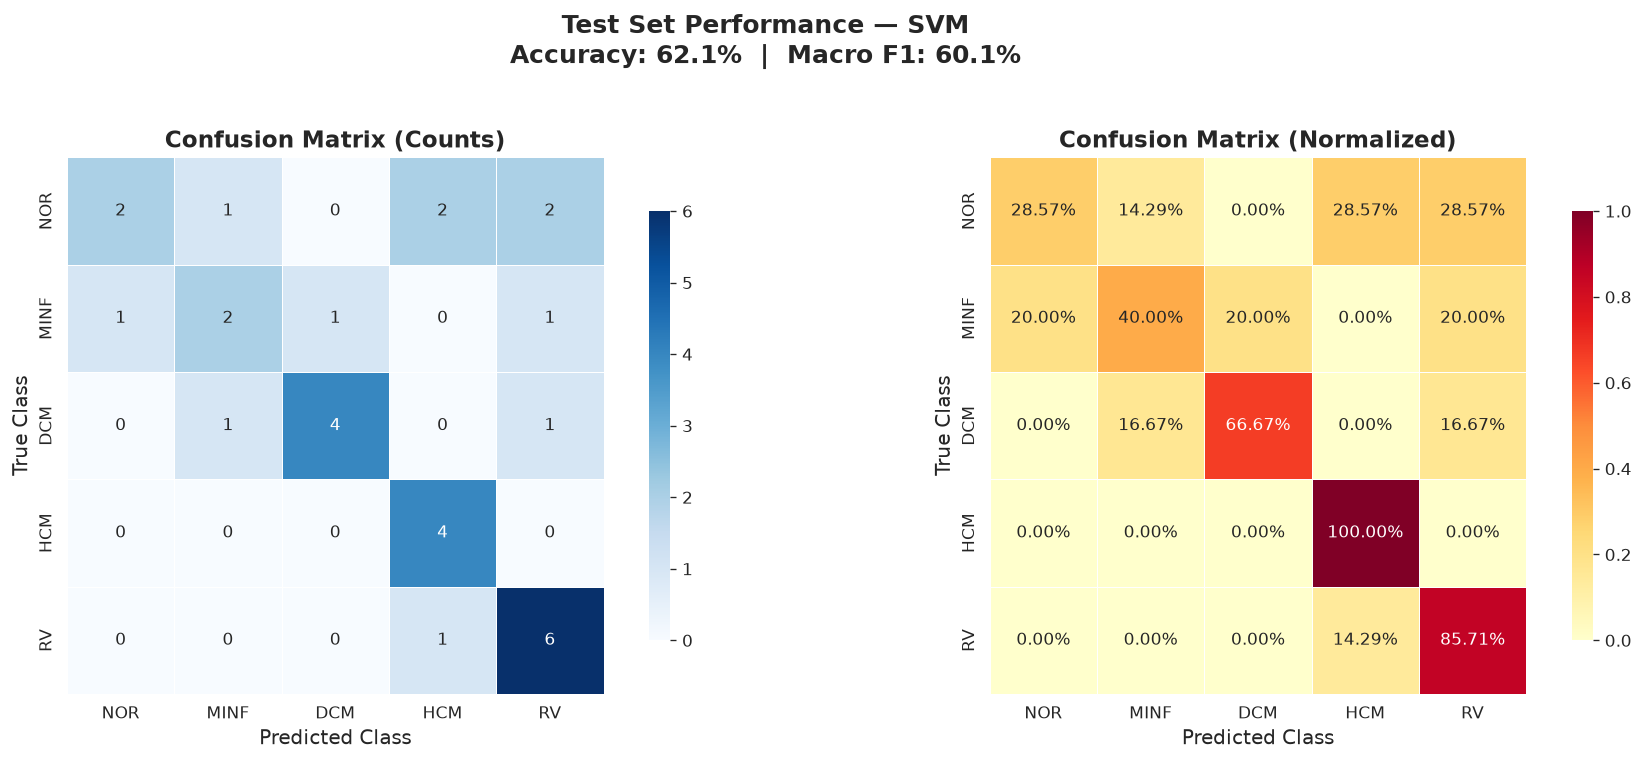

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CONFUSION MATRIX VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════════════

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            square=True, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
ax.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Normalized (percentages)
ax = axes[1]
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)  # Handle division by zero
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            square=True, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('True Class', fontsize=12)
ax.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')

fig.suptitle(
    f'Test Set Performance — {best_overall_name}\n'
    f'Accuracy: {test_accuracy:.1%}  |  Macro F1: {test_f1_macro:.1%}',
    fontsize=15, fontweight='bold', y=1.04
)

plt.tight_layout()
plt.show()

---
## 📊 Pipeline Summary

| Phase | Description | Status |
|-------|-------------|--------|
| **1. Data Loading** | Loaded 4D NIfTI volumes with `nibabel`, parsed `Info.cfg` labels | ✅ |
| **2. Preprocessing** | Z-score normalization + CLAHE enhancement | ✅ |
| **3. ROI Detection** | Temporal variance map → Otsu threshold → bounding box crop | ✅ |
| **4. Feature Engineering** | 40+ temporal, shape, intensity, and clinical features | ✅ |
| **5. Dimensionality Reduction** | PCA (95% variance) + t-SNE visualization | ✅ |
| **6. Classification** | Grid search over RF, SVM, MLP with 5-fold stratified CV | ✅ |
| **7. Test Evaluation** | Final metrics on unseen test set with confusion matrix | ✅ |

### Key Design Decisions
- **Temporal variance** for automatic heart ROI detection avoids manual segmentation
- **Mid-ventricular slice selection** (middle third) focuses on the most diagnostically relevant region
- **Ejection fraction approximation** from volume curves captures the primary clinical biomarker
- **PCA before classification** reduces overfitting on high-dimensional handcrafted features
- **Macro F1** scoring handles the balanced ACDC class distribution appropriately